## Life Expectancy Drivers
Analyzing what predicts life expectancy across countries using World Bank data (2015-2024). Part 1 builds a regression model, part 2 looks at which countries are improving fastest over time.

In [1]:
import requests
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score
from scipy import stats
import pycountry
from sklearn.linear_model import LinearRegression


In [2]:
# World Bank indicator codes we're pulling, with friendly column names
indicators = {
    "life_expectancy":    "SP.DYN.LE00.IN",
    "gdp_per_capita":     "NY.GDP.PCAP.CD",
    "health_spending":    "SH.XPD.CHEX.GD.ZS",
    "education_spending": "SE.XPD.TOTL.GD.ZS",
    "sanitation_access":  "SH.STA.SMSS.ZS",
    "water_access":       "SH.H2O.SMDW.ZS",
    "under5_mortality":   "SH.DYN.MORT",
}

start_year = 2015
end_year = 2024

In [3]:
# Function to fetch one indicator from the World Bank API for a range of years

def get_indicator_range(code, start_year, end_year):
    url = f"https://api.worldbank.org/v2/country/all/indicator/{code}"
    params = {"date": f"{start_year}:{end_year}", "format": "json", "per_page": 20000}

    response = requests.get(url, params=params)
    data = response.json()

    # checking the response is shaped how we expect before parsing
    if len(data) < 2:
        print("Problem with code:", code)
        print(data)
        return pd.DataFrame()

    records = data[1]
    rows = []
    for r in records:
        rows.append({
            "country_code": r["countryiso3code"],
            "country": r["country"]["value"],
            "year": int(r["date"]),
            "value": r["value"],
        })

    return pd.DataFrame(rows)

In [4]:
# Fetching all indicators and keeping each country's most recent available value

def data_load():
    all_data = {}
    for name, code in indicators.items():
        df = get_indicator_range(code, start_year, end_year)

        if df.empty:
            print("Skipping", name, "-- no data returned")
            continue

        df = df.dropna(subset=["value"])
        df = df.sort_values("year", ascending=False)
        df = df.drop_duplicates(subset="country_code", keep="first")
        all_data[name] = df
        print(name, ":", df["country_code"].nunique(), "countries")

    return all_data

all_data = data_load()

life_expectancy : 261 countries
gdp_per_capita : 257 countries
health_spending : 237 countries
education_spending : 233 countries
sanitation_access : 173 countries
water_access : 176 countries
under5_mortality : 240 countries


In [5]:
# Merging all indicators into one table, matched on country_code

merged = all_data["life_expectancy"][["country_code", "country", "value"]].copy()
merged = merged.rename(columns={"value": "life_expectancy"})

for name in indicators:
    if name == "life_expectancy":
        continue
    temp = all_data[name][["country_code", "value"]].rename(columns={"value": name})
    merged = merged.merge(temp, on="country_code", how="left")

merged.head(10)

,country_code,country,life_expectancy,gdp_per_capita,health_spending,education_spending,sanitation_access,water_access,under5_mortality
0,AUT,Austria,81.995122,58268.878765,11.832563,5.277490,98.502318,98.891536,3.3
1,AZE,Azerbaijan,74.576000,7294.642761,4.271135,3.660360,68.003345,57.811828,17.9
2,BHS,"Bahamas, The",74.710000,39455.446655,6.302608,2.741916,NaN,NaN,12.4
3,BHR,Bahrain,81.423000,29717.142461,3.995624,1.887782,93.352599,98.903976,8.8
4,BGD,Bangladesh,74.930000,2593.416117,2.170146,2.034385,37.320498,59.125426,30.5
5,BRB,Barbados,76.332000,26897.200204,5.404638,3.555932,NaN,NaN,9.8
6,AGO,Angola,64.805000,2720.819007,2.546929,2.512737,NaN,NaN,49.0
7,BLR,Belarus,74.365341,8605.609546,7.081674,5.045940,74.437110,93.059755,2.3
8,UKR,Ukraine,74.692000,5391.622559,8.202748,5.140100,92.393890,87.868377,7.9
9,ARE,United Arab Emirates,83.069000,50273.512624,4.970951,3.894040,98.449700,98.641317,4.8


In [7]:
valid_codes = {c.alpha_3 for c in pycountry.countries}

merged = merged[merged["country_code"].isin(valid_codes)]

print("Rows before dropping missing values:", len(merged))
clean = merged.dropna()
print("Rows after dropping missing values:", len(clean))
clean.head()

Rows before dropping missing values: 215
Rows after dropping missing values: 113


,country_code,country,life_expectancy,gdp_per_capita,health_spending,education_spending,sanitation_access,water_access,under5_mortality
0,AUT,Austria,81.995122,58268.878765,11.832563,5.277490,98.502318,98.891536,3.3
1,AZE,Azerbaijan,74.576000,7294.642761,4.271135,3.660360,68.003345,57.811828,17.9
3,BHR,Bahrain,81.423000,29717.142461,3.995624,1.887782,93.352599,98.903976,8.8
4,BGD,Bangladesh,74.930000,2593.416117,2.170146,2.034385,37.320498,59.125426,30.5
7,BLR,Belarus,74.365341,8605.609546,7.081674,5.045940,74.437110,93.059755,2.3


In [8]:
# GDP and under-5 mortality are both heavily skewed, log-transforming both before modeling
clean = clean.copy()
clean["log_gdp_per_capita"] = np.log(clean["gdp_per_capita"])
clean["log_under5_mortality"] = np.log(clean["under5_mortality"])

clean[["gdp_per_capita", "log_gdp_per_capita", "under5_mortality", "log_under5_mortality"]].head()

,gdp_per_capita,log_gdp_per_capita,under5_mortality,log_under5_mortality
0,58268.878765,10.972823,3.3,1.193922
1,7294.642761,8.894895,17.9,2.884801
3,29717.142461,10.299479,8.8,2.174752
4,2593.416117,7.860731,30.5,3.417727
7,8605.609546,9.060170,2.3,0.832909


In [9]:
clean.describe()

,life_expectancy,gdp_per_capita,health_spending,education_spending,sanitation_access,water_access,under5_mortality,log_gdp_per_capita,log_under5_mortality
count,113.000000,113.000000,113.000000,113.000000,113.000000,113.000000,113.000000,113.000000,113.000000
mean,74.832108,25319.255944,7.326012,4.391809,63.249200,68.780748,20.654867,9.193429,2.413333
std,7.565487,37291.234297,3.606802,2.059072,29.954460,30.917063,24.054844,1.527813,1.130169
min,54.635000,416.871146,1.326516,0.319069,8.051033,6.217488,1.300000,6.032777,0.262364
25%,69.225000,3028.254813,4.598805,3.229743,34.692024,42.941389,4.000000,8.015742,1.386294
50%,76.023000,9397.909429,7.081674,4.252850,69.278338,76.442194,10.400000,9.148243,2.341806
75%,81.839024,34301.031869,8.921694,5.312090,92.393890,98.144873,29.100000,10.442931,3.370738
max,86.497000,288001.574856,27.089685,16.390530,100.000000,100.000000,115.600000,12.570721,4.750136


In [10]:
# Checking a couple of extreme values flagged in describe()
clean.sort_values("gdp_per_capita", ascending=False).head(3)[["country", "gdp_per_capita"]]
clean.sort_values("health_spending", ascending=False).head(3)[["country", "health_spending"]]

,country,health_spending
30,Tuvalu,27.089685
189,Naoero,18.210760
11,United States,16.694149


#### Exploring the data

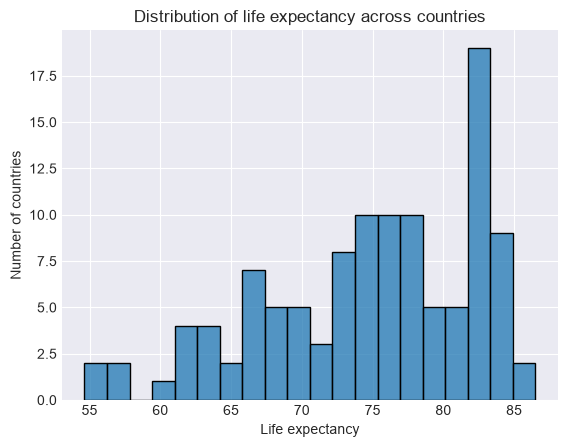

In [11]:
plt.style.use('seaborn-v0_8-darkgrid')

sns.histplot(clean["life_expectancy"], bins=20)
plt.xlabel("Life expectancy")
plt.ylabel("Number of countries")
plt.title("Distribution of life expectancy across countries")
plt.show()

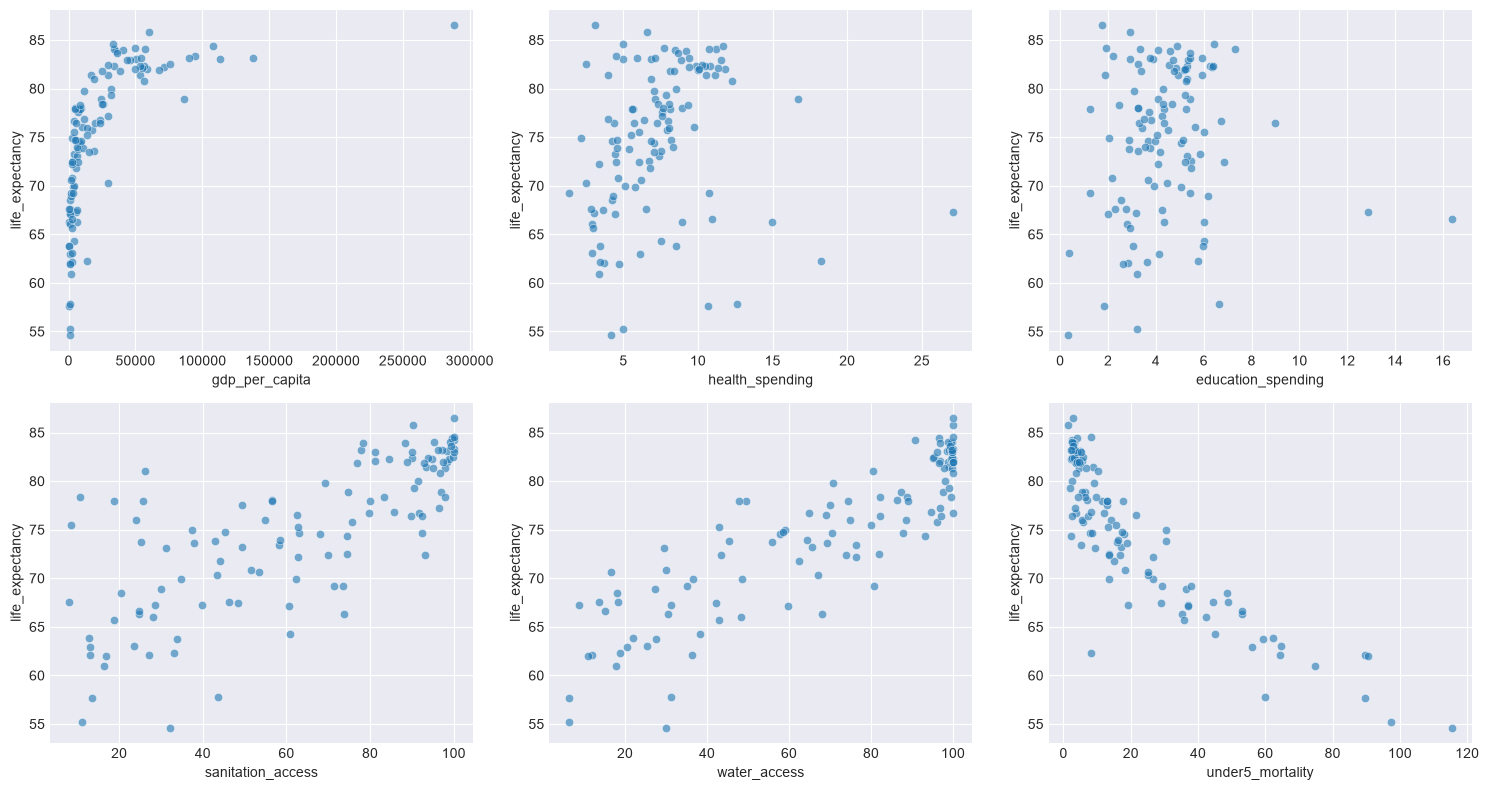

In [12]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))

pairs = [
    ("gdp_per_capita", axes[0, 0]),
    ("health_spending", axes[0, 1]),
    ("education_spending", axes[0, 2]),
    ("sanitation_access", axes[1, 0]),
    ("water_access", axes[1, 1]),
    ("under5_mortality", axes[1, 2]),
]

for column, ax in pairs:
    sns.scatterplot(data=clean, x=column, y="life_expectancy", ax=ax, alpha=0.6)

plt.tight_layout()
plt.show()

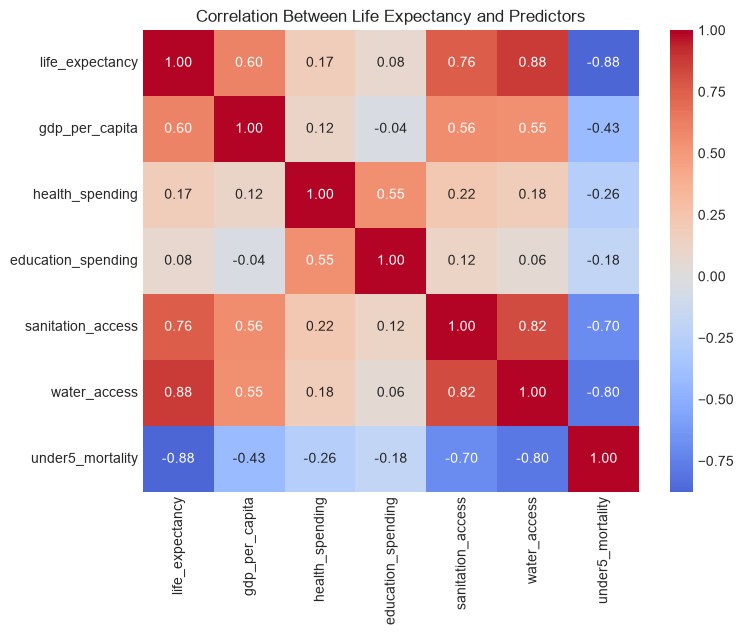

In [13]:
plt.figure(figsize=(8, 6))
corr = clean[["life_expectancy", "gdp_per_capita", "health_spending",
              "education_spending", "sanitation_access", "water_access",
              "under5_mortality"]].corr()
sns.heatmap(corr, annot=True, cmap="coolwarm", center=0, fmt=".2f")
plt.title("Correlation Between Life Expectancy and Predictors")
plt.show()

Sanitation, water access, and under-5 mortality are all fairly correlated with each other (0.7-0.88), which likely means the regression will struggle to fully separate their individual effects. Worth checking with VIF later.

### Regression

In [14]:
feature_columns = [
    "log_gdp_per_capita",
    "health_spending",
    "education_spending",
    "sanitation_access",
    "water_access",
    "log_under5_mortality",
]

X = clean[feature_columns]
y = clean["life_expectancy"]

X = sm.add_constant(X)
model = sm.OLS(y, X).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:        life_expectancy   R-squared:                       0.860
Model:                            OLS   Adj. R-squared:                  0.852
Method:                 Least Squares   F-statistic:                     108.4
Date:                Thu, 30 Jul 2026   Prob (F-statistic):           6.38e-43
Time:                        23:57:08   Log-Likelihood:                -277.46
No. Observations:                 113   AIC:                             568.9
Df Residuals:                     106   BIC:                             588.0
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                           coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------
const                   67.4404 

R² of 0.86, the six variables explain most of the variation in life expectancy across these 113 countries. Under-5 mortality dominates the effect size, which isn't too surprising since it's close to definitionally tied to how life expectancy gets calculated. Health spending came out negative, more likely reverse causality (countries with worse outcomes spend more reactively) than a real effect.

In [15]:
# Standardizing so coefficients are comparable across variables measured in different units
X_features = clean[feature_columns]
X_standardized = (X_features - X_features.mean()) / X_features.std()
y_standardized = (clean["life_expectancy"] - clean["life_expectancy"].mean()) / clean["life_expectancy"].std()

X_standardized = sm.add_constant(X_standardized)
model_standardized = sm.OLS(y_standardized, X_standardized).fit()

importance = model_standardized.params.drop("const").sort_values(key=abs, ascending=False)
print(importance)

log_under5_mortality   -0.454808
water_access            0.336370
log_gdp_per_capita      0.234263
health_spending        -0.103958
education_spending      0.043114
sanitation_access      -0.042883
dtype: float64


Under-5 mortality and water access are the two strongest predictors once everything's on the same scale, both bigger than GDP. Sanitation and education spending drop out almost completely, probably because their signal overlaps with water access and mortality.

### Multicollinearity (VIF)

In [16]:
X_with_const = sm.add_constant(clean[feature_columns])

vif_data = pd.DataFrame()
vif_data["variable"] = X_with_const.columns
vif_data["VIF"] = [variance_inflation_factor(X_with_const.values, i) for i in range(X_with_const.shape[1])]
vif_data = vif_data[vif_data["variable"] != "const"]

vif_data.sort_values("VIF", ascending=False)

,variable,VIF
6,log_under5_mortality,6.937940
1,log_gdp_per_capita,5.826466
5,water_access,5.691527
4,sanitation_access,3.440897
2,health_spending,1.637993
3,education_spending,1.461964


Under-5 mortality, GDP, and water access all sit around 5.7-6.9, moderate multicollinearity. Not severe enough to throw the regression out, but enough that these three should be read as a cluster of related development signals rather than fully separate effects.

#### Train/test validation

In [17]:
X_train, X_test, y_train, y_test = train_test_split(
    clean[feature_columns], clean["life_expectancy"], test_size=0.2, random_state=42
)

X_train_const = sm.add_constant(X_train)
X_test_const = sm.add_constant(X_test)

train_model = sm.OLS(y_train, X_train_const).fit()
predictions = train_model.predict(X_test_const)
test_r2 = r2_score(y_test, predictions)

print("R-squared on training data:", round(train_model.rsquared, 3))
print("R-squared on unseen test data:", round(test_r2, 3))

R-squared on training data: 0.861
R-squared on unseen test data: 0.816


R² held up well on the held-out 20% (0.82 vs 0.86 on training), suggesting the model isn't just memorizing quirks of these 113 countries. Test set is only 23 countries though, so this single split shouldn't be read as a precise number, cross-validation would give a steadier read.

#### Residual diagnostics

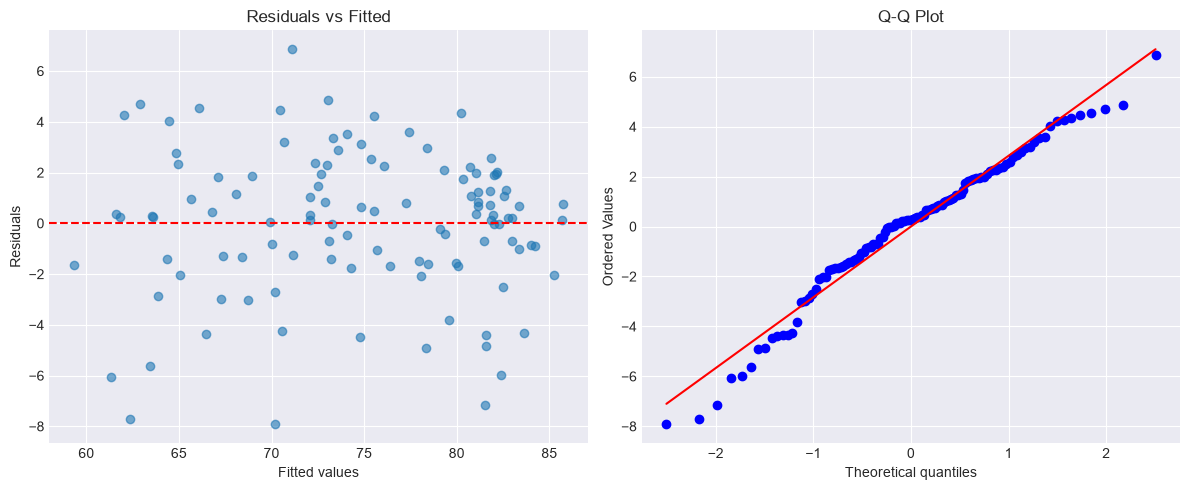

In [18]:
fitted_values = model.fittedvalues
residuals = model.resid

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].scatter(fitted_values, residuals, alpha=0.6)
axes[0].axhline(y=0, color="red", linestyle="--")
axes[0].set_xlabel("Fitted values")
axes[0].set_ylabel("Residuals")
axes[0].set_title("Residuals vs Fitted")

stats.probplot(residuals, dist="norm", plot=axes[1])
axes[1].set_title("Q-Q Plot")

plt.tight_layout()
plt.show()

Residuals vs fitted look reasonably random, no obvious pattern. The Q-Q plot shows heavier tails than a normal distribution though, especially at both ends, meaning the p-values and confidence intervals above are approximate rather than exact, and the model is least reliable at the extremes of the life expectancy range.

In [19]:
clean["residual"] = model.resid

# Countries the model most underpredicts
clean.sort_values("residual", ascending=False).head(5)[["country", "life_expectancy", "residual"]]

,country,life_expectancy,residual
241,Lebanon,77.945,6.858449
137,Peru,77.941,4.869309
237,Malawi,67.561,4.689880
190,Nepal,70.636,4.535397
4,Bangladesh,74.930,4.464849


In [20]:
# Countries the model most overpredicts
clean.sort_values("residual").head(5)[["country", "life_expectancy", "residual"]]

,country,life_expectancy,residual
189,Naoero,62.279000,-7.918164
172,Nigeria,54.635000,-7.699661
7,Belarus,74.365341,-7.157989
65,Chad,55.238000,-6.074981
240,Latvia,76.429268,-5.980878


Lebanon, Peru, Malawi, Nepal, and Bangladesh all do noticeably better on life expectancy than their GDP, spending, and infrastructure numbers alone predict, several are known for strong primary healthcare systems relative to income.

The countries the model most overpredicts split into two different stories. Nigeria and Chad already have low life expectancy and still do worse than their numbers suggest, likely conflict and health-system disruption not captured by any of these indicators. Belarus and Latvia are closer to the opposite case, decent income and infrastructure but life expectancy well below what that would normally predict, which lines up with the well-documented Eastern European mortality pattern driven by alcohol, smoking, and cardiovascular disease rather than a resource gap.

### Improvement over time

which countries are gaining the fastest, and where that trend might be headed if it keeps up.

In [24]:
# Getting life expectancy history for every country, not just the latest value this time
life_exp_history = get_indicator_range("SP.DYN.LE00.IN", start_year, end_year)
life_exp_history = life_exp_history[life_exp_history["country_code"].isin(valid_codes)]
life_exp_history = life_exp_history.dropna(subset=["value"])

# only keeping countries with enough years of data to fit a trend on
counts = life_exp_history.groupby("country_code").size()
enough_data = counts[counts >= 5].index
life_exp_history = life_exp_history[life_exp_history["country_code"].isin(enough_data)]

print("Countries with enough history:", life_exp_history["country_code"].nunique())
life_exp_history.head()

Countries with enough history: 215


,country_code,country,year,value
480,AFG,Afghanistan,2024,66.289
481,AFG,Afghanistan,2023,66.035
482,AFG,Afghanistan,2022,65.617
483,AFG,Afghanistan,2021,60.417
484,AFG,Afghanistan,2020,61.454


In [27]:
# fitting a straight-line trend per country to see who's improving fastest

trend_results = []

for code, group in life_exp_history.groupby("country_code"):
    group = group.sort_values("year")
    X_year = group[["year"]]
    y_life = group["value"]

    reg = LinearRegression().fit(X_year, y_life)
    slope = reg.coef_[0]  # years of life expectancy gained per calendar year
    latest_year = group["year"].max()
    latest_value = group.loc[group["year"] == latest_year, "value"].values[0]

    trend_results.append({
        "country_code": code,
        "country": group["country"].iloc[0],
        "current_life_expectancy": latest_value,
        "latest_year": latest_year,
        "yearly_improvement": slope,
    })

trends = pd.DataFrame(trend_results)
trends.sort_values("yearly_improvement", ascending=False).head(10)

,country_code,country,current_life_expectancy,latest_year,yearly_improvement
176,SSD,South Sudan,57.738,2024,2.620079
185,SYR,Syrian Arab Republic,72.560,2024,1.115000
182,SWZ,Eswatini,64.264,2024,1.000103
138,NAM,Namibia,67.516,2024,0.736848
171,SLE,Sierra Leone,61.964,2024,0.689739
213,ZMB,Zambia,66.528,2024,0.657194
113,LSO,Lesotho,57.798,2024,0.595564
30,BWA,Botswana,69.293,2024,0.584970
136,MWI,Malawi,67.561,2024,0.534867
133,MOZ,Mozambique,63.797,2024,0.531509


South Sudan stands out sharply, gaining roughly 2.6 years of life expectancy per year, close to 4x the next fastest country. Syria is also near the top. The rest of the top 10 is almost entirely Southern and Eastern African countries (Eswatini, Namibia, Zambia, Lesotho, Botswana, Malawi, Mozambique).

Worth being careful about what "fastest improving" actually means here, a steep upward slope just says life expectancy moved up quickly over this window. It doesn't say whether that's steady progress or a bounce back from a low point, and it doesn't say why. That would need more than this trend line to answer.

In [28]:
forecast_years = 5

trends["projected_life_expectancy"] = (
    trends["current_life_expectancy"] + trends["yearly_improvement"] * forecast_years   
)

trends.sort_values("yearly_improvement", ascending=False).head(15)[[
    "country", "current_life_expectancy", "yearly_improvement", "projected_life_expectancy"
]]

,country,current_life_expectancy,yearly_improvement,projected_life_expectancy
176,South Sudan,57.738,2.620079,70.838394
185,Syrian Arab Republic,72.560,1.115000,78.135000
182,Eswatini,64.264,1.000103,69.264515
138,Namibia,67.516,0.736848,71.200242
171,Sierra Leone,61.964,0.689739,65.412697
213,Zambia,66.528,0.657194,69.813970
113,Lesotho,57.798,0.595564,60.775818
30,Botswana,69.293,0.584970,72.217848
136,Malawi,67.561,0.534867,70.235333
133,Mozambique,63.797,0.531509,66.454545


None of these projections land above 85, which is at least a basic sanity check passed. But a straight-line extrapolation only works if the recent trend keeps going exactly as-is, and that's a shaky assumption for a country like South Sudan, recovery from a low point rarely continues at the same rate once some ground has been recovered. These projections should be read as "if the recent trend holds," not as a real forecast.

In [29]:
max_life = 85

trends["room_to_grow"] = max_life - trends["current_life_expectancy"]

# standardizing both pieces so one doesn't dominate just because of its scale
trends["improvement_z"] = (trends["yearly_improvement"] - trends["yearly_improvement"].mean()) / trends["yearly_improvement"].std()
trends["room_z"] = (trends["room_to_grow"] - trends["room_to_grow"].mean()) / trends["room_to_grow"].std()

trends["momentum_score"] = trends["improvement_z"] + trends["room_z"]

trends.sort_values("momentum_score", ascending=False).head(15)[[
    "country", "current_life_expectancy", "yearly_improvement", "room_to_grow", "momentum_score"
]]

,country,current_life_expectancy,yearly_improvement,room_to_grow,momentum_score
176,South Sudan,57.738,2.620079,27.262,11.929748
182,Eswatini,64.264,1.000103,20.736,4.652650
113,Lesotho,57.798,0.595564,27.202,3.973008
185,Syrian Arab Republic,72.560,1.115000,12.440,3.937997
187,Chad,55.238,0.454212,29.762,3.777786
171,Sierra Leone,61.964,0.689739,23.036,3.757345
141,Nigeria,54.635,0.309127,30.365,3.292911
174,"Somalia, Fed. Rep.",58.967,0.432055,26.033,3.166801
138,Namibia,67.516,0.736848,17.484,3.162138
213,Zambia,66.528,0.657194,18.472,2.988244


South Sudan still tops it either way, it has both the fastest slope and the most room left. But countries like Nigeria, Somalia, and Chad climb in here despite slower improvement, just because they're starting lower with more room ahead. Worth noting the 85-year ceiling is a judgment call, not a fixed number.

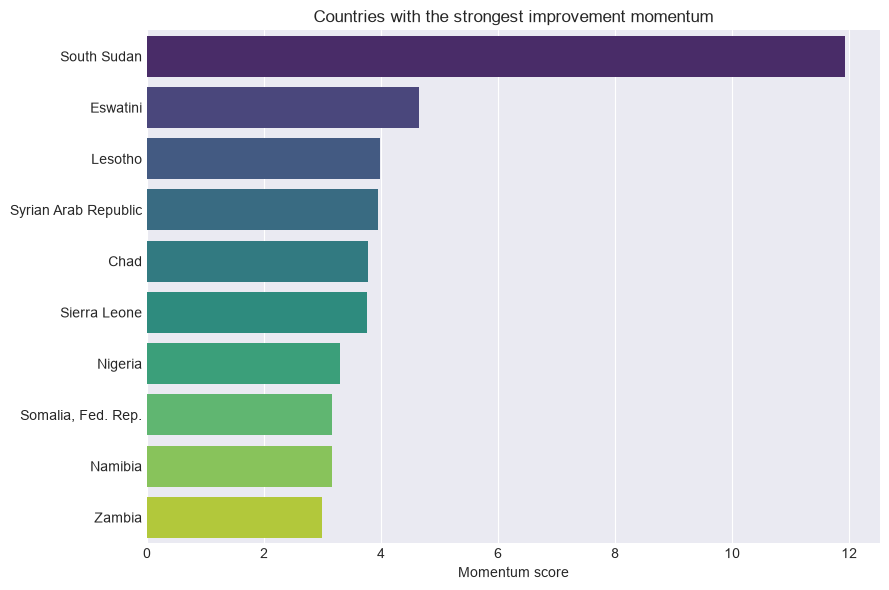

In [31]:
top_movers = trends.sort_values("momentum_score", ascending=False).head(10)

plt.figure(figsize=(9, 6))
sns.barplot(data=top_movers, y="country", x="momentum_score", hue="country", palette="viridis", legend=False)
plt.xlabel("Momentum score")
plt.ylabel("")
plt.title("Countries with the strongest improvement momentum")
plt.tight_layout()
plt.show()